In [2]:
#fetching the data from online git repository.
from sklearn.model_selection import train_test_split
import os
import tarfile
import numpy as np
import matplotlib.pyplot as plt
from six.moves import urllib
import pandas as pd

csv_path = r"C:\Desktop\ml adda\ML-adda\Housing_Prediction\Dataset\housing.csv"

def load_housing_data(path=csv_path):
    
    return pd.read_csv(path)


housing = load_housing_data()
housing.head()


train_set , test_set = train_test_split(housing,test_size=0.2,random_state=42)




In [3]:

housing['incom_cat'] = pd.cut(housing["median_income"],bins = [0.,1.5,3.0,4.5,6.,np.inf],labels=[1,2,3,4,5])
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
for train_index , test_index in split.split(housing,housing['incom_cat']):
  strat_trainset = housing.loc[train_index]
  strat_testset = housing.loc[test_index]


 

median_house_value       1.000000
median_income            0.687151
rooms_per_house          0.146255
total_rooms              0.135140
housing_median_age       0.114146
households               0.064590
total_bedrooms           0.047781
popullation_per_house   -0.021991
population              -0.026882
longitude               -0.047466
latitude                -0.142673
bedrooms_per_rooms      -0.259952
Name: median_house_value, dtype: float64
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
12655    -121.46     38.52                29.0       3873.0           797.0   
15502    -117.23     33.09                 7.0       5320.0           855.0   
2908     -119.04     35.37                44.0       1618.0           310.0   
14053    -117.13     32.75                24.0       1877.0           519.0   
20496    -118.70     34.28                27.0       3536.0           646.0   
...          ...       ...                 ...          ...             ...  

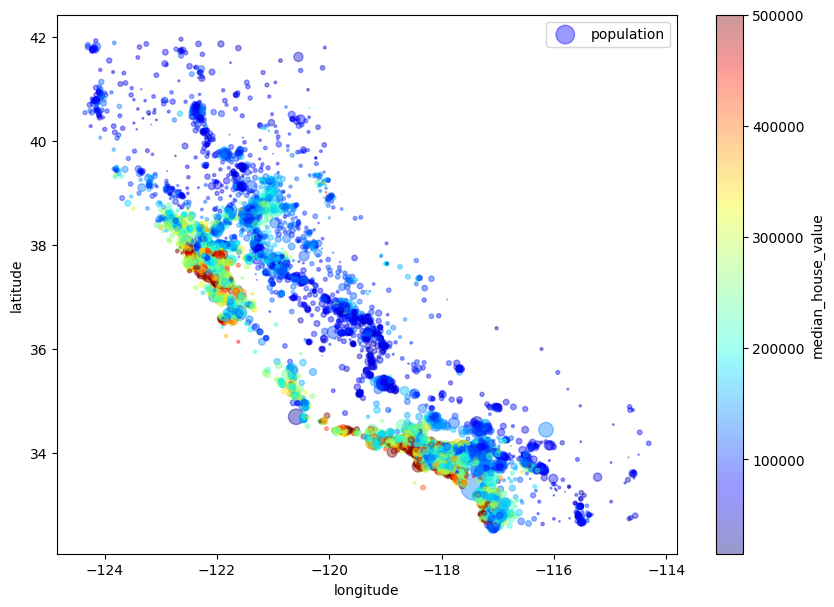

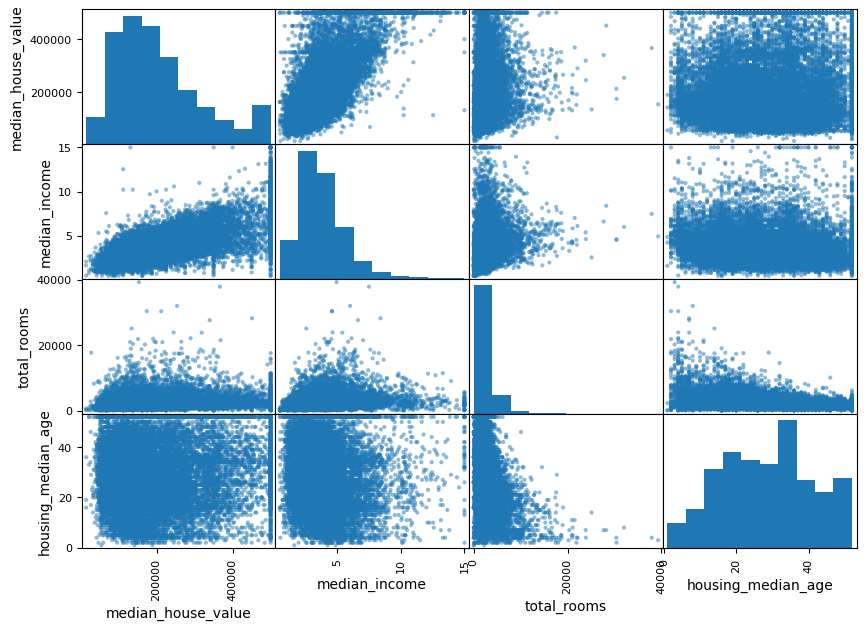

In [4]:
housing = strat_trainset.copy()
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
 s=housing["population"]/100, label="population", figsize=(10,7),
 c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
)


from pandas.plotting import scatter_matrix
attributes = ["median_house_value", "median_income","total_rooms","housing_median_age"]
scatter_matrix(housing[attributes],figsize=(10,7))
housing["bedrooms_per_rooms"] = housing["total_bedrooms"]/housing["total_rooms"]
housing ["rooms_per_house"] = housing ["total_rooms"]/housing["households"]
housing["popullation_per_house"] = housing["population"]/housing ["households"]

numeric_columns = housing.select_dtypes(include=['number'])
corr_matrix = numeric_columns.corr()
print(corr_matrix["median_house_value"].sort_values(ascending=False))
housing = strat_trainset.drop("median_house_value", axis=1)
housing_labels = strat_trainset["median_house_value"].copy()
housing_test = strat_testset.drop("median_house_value", axis=1)
housing_labels_test = strat_testset["median_house_value"].copy()

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
housing_num = housing.drop("ocean_proximity",axis = 1)
imputer.fit(housing_num)
imputer.statistics_
imputer.transform(housing_num)
print(housing_num)










In [5]:
from sklearn.preprocessing import OneHotEncoder
housing_cat_OP = housing[["ocean_proximity"]]
cat_encoder = OneHotEncoder()
one_hot_encoded = cat_encoder.fit_transform(housing_cat_OP)
one_hot_encoded 
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
num_pipeline= Pipeline(
  [
    ('imputer', SimpleImputer(strategy="median")),
    ('std_scaler',StandardScaler()),
  ]
)
from sklearn.compose import ColumnTransformer
num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]
full_pipeline = ColumnTransformer([
  ("num",num_pipeline,num_attribs),
("cat" , OneHotEncoder() , cat_attribs),])
housing_prepared = full_pipeline.fit_transform(housing)
housing_prepared_test = full_pipeline.transform(housing_test)
print(housing_prepared_test)






[[ 0.59229422 -0.71065803  0.02756357 ...  0.          0.
   0.        ]
 [-0.42180959 -0.35049119 -0.37006852 ...  0.          0.
   0.        ]
 [ 0.56232071 -0.64985064  0.5842485  ...  0.          0.
   0.        ]
 ...
 [-0.07211862 -0.56097831  1.14093342 ...  0.          0.
   0.        ]
 [ 0.83208232 -0.93985512  0.10708999 ...  0.          0.
   0.        ]
 [ 0.50736927 -0.67791559  0.5842485  ...  0.          0.
   0.        ]]


In [6]:
#training model 
# trying linear regresssion first ->
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)
housing_prepared_pd = pd.DataFrame(housing_prepared)
some_data = housing_prepared_pd.iloc[:5]
some_labels = housing_labels.iloc[:5]
print("Predictions:", lin_reg.predict(some_data))
print("Labels:", list(some_labels))
# using rmse metrics lets check its accuracy.
from sklearn.metrics import mean_squared_error
housing_predictions = lin_reg.predict(housing_prepared_test)
lin_mse = mean_squared_error(housing_labels_test, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
print(lin_rmse) 



Predictions: [ 87710.9184376  312666.78080576 148193.92872405 181973.84391033
 242269.47566914]
Labels: [72100.0, 279600.0, 82700.0, 112500.0, 238300.0]
67238.68522644627


In [7]:
from sklearn.tree import DecisionTreeRegressor
des_tree = DecisionTreeRegressor()
housing_prepared_pd_test = pd.DataFrame(housing_prepared_test)
des_tree.fit(housing_prepared, housing_labels)
print(des_tree.predict(housing_prepared_test))
print(list(housing_labels_test))
from sklearn.metrics import mean_squared_error
housing_predictions = des_tree.predict(housing_prepared_test)
des_reg_mse = mean_squared_error(housing_labels_test, housing_predictions)
des_reg_rmse = np.sqrt(des_reg_mse)
print(des_reg_rmse) 



[500001. 158200. 216900. ... 443000. 317900. 184800.]
[500001.0, 162500.0, 204600.0, 159700.0, 184000.0, 151900.0, 104900.0, 500001.0, 367400.0, 346500.0, 337000.0, 59200.0, 212500.0, 274600.0, 227100.0, 115800.0, 97600.0, 85500.0, 337400.0, 366200.0, 219700.0, 279900.0, 230800.0, 59100.0, 89300.0, 67200.0, 293800.0, 162100.0, 91700.0, 145600.0, 175900.0, 116300.0, 167900.0, 96600.0, 60800.0, 411900.0, 135300.0, 235500.0, 80600.0, 318800.0, 171900.0, 338600.0, 195200.0, 267700.0, 228900.0, 163900.0, 75000.0, 153100.0, 95300.0, 325700.0, 66300.0, 93800.0, 350000.0, 248900.0, 500001.0, 170100.0, 346800.0, 208000.0, 435700.0, 164400.0, 142600.0, 500001.0, 294100.0, 349600.0, 209200.0, 147200.0, 55000.0, 180800.0, 162900.0, 397000.0, 373400.0, 255900.0, 193700.0, 149700.0, 421600.0, 174800.0, 154200.0, 178400.0, 185400.0, 51600.0, 150400.0, 279900.0, 182100.0, 73100.0, 331500.0, 361900.0, 238300.0, 169800.0, 500001.0, 213000.0, 84800.0, 290000.0, 180000.0, 97200.0, 73800.0, 150700.0, 12800

In [8]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(des_tree,housing_prepared,housing_labels,scoring="neg_mean_squared_error",cv = 10)
tree_rmse_scores = np.sqrt(-scores)
def display_scores(scores):
  print("scores:",scores)
  print("Mean:",scores.mean())
  print("Standard deviation",scores.std())
display_scores(tree_rmse_scores)
scores1 = cross_val_score(lin_reg,housing_prepared,housing_labels,scoring="neg_mean_squared_error",cv = 10)
lin_rmse_scores = np.sqrt(-scores1)
display_scores(lin_rmse_scores)


scores: [69860.84054258 70062.72509159 66372.77238287 70105.06632687
 68316.80353399 67800.34576468 72010.72079509 69959.47772703
 67852.50662313 71329.77875199]
Mean: 69367.10375398239
Standard deviation 1651.7218570486737
scores: [72098.22665202 65263.25382431 67474.73970669 69344.34356573
 66405.23454953 72763.65486499 70271.51498924 69326.8790595
 66674.88791569 70584.58383018]
Mean: 69020.731895787
Standard deviation 2377.8463322927123


In [9]:
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor()
forest_reg.fit(housing_prepared,housing_labels)
scores2 = cross_val_score(forest_reg,housing_prepared,housing_labels,scoring="neg_mean_squared_error",cv = 10)
forest_rmse_scores = np.sqrt(-scores2)
display_scores(forest_rmse_scores)






scores: [50638.37736175 49063.12406937 45917.88449141 50783.6801242
 47736.47159808 49412.4012495  51896.64422017 49011.57671352
 47245.20662053 53023.58087058]
Mean: 49472.89473191191
Standard deviation 2062.975640793001


In [10]:
import joblib
joblib.dump(forest_reg,"forest_reg.pkl")
joblib.dump(lin_reg,"lin_reg.pkl")
joblib.dump(des_tree,"des_tree.pkl")



['des_tree.pkl']

In [11]:
from sklearn.model_selection import GridSearchCV
param_grid = [
 {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
 {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
 ]
forest_reg = joblib.load("forest_reg.pkl")
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
 scoring='neg_mean_squared_error',
return_train_score=True)
grid_search.fit(housing_prepared, housing_labels)
grid_search.best_estimator_


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",30
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",8
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [12]:
final_model = grid_search.best_estimator_
final_predictions = final_model.predict(housing_prepared_test)

final_mse = mean_squared_error(housing_labels_test,final_predictions)
final_rmse = np.sqrt(final_mse)
print("rmse value error : ",final_rmse)
from sklearn.metrics import r2_score
r2 = r2_score(housing_labels_test, final_predictions)
r2_percentage = r2 * 100
print("An R-squared value percentage of :",r2_percentage,"%")





rmse value error :  48002.82639177907
An R-squared value percentage of : 82.31992023964384 %
